# Lab 4: Feature Engineering — การจำแนกพืช PlantCLEF

| | |
|---|---|
| **วิชา** | 01076251 Machine Learning for Data Science |
| **หัวข้อ** | Feature Engineering และการทำโมเดลแบบ Hybrid (ดึงฟีเจอร์ด้วย Pre-trained + ML/Vector Search) |
| **ผู้จัดทำ** | ปิยังกูร ปัสสาวะกัง (6810405691) และ ศิวภูมิ พรหมจรรย์ (6810405887) |

---
## คำถามหลักของแลปนี้

1. **Missing Values**: ตรวจสอบรูปภาพที่มีปัญหา เช่น เปิดไม่ได้ รูปเล็กเกินไป สีไม่ใช่ RGB หรือแถวข้อมูลว่าง พร้อมวิธีแก้
2. **Feature Operations**: สิ่งที่ต้องทำกับรูปภาพก่อนส่งเข้าโมเดล (ปรับขนาด ปรับค่าสี จัดรูปทรงข้อมูล)
3. **Data Leakage**: วิธีป้องกันไม่ให้ข้อมูลชุดทดสอบรั่วเข้าไปตอนเทรน
4. **Feature Selection และการเลือกโมเดล**: ดูว่าฟีเจอร์ไหนสำคัญ วิเคราะห์รูปภาพที่ควรใช้และไม่ควรใช้ พร้อมเปรียบเทียบโมเดล 3 ตัว และทำ Vector Search เพื่อใช้งานจริง

---
## 1. ที่มาของปัญหาและแนวทาง Hybrid

### 1.1 ปัญหาของการจำแนกพืชในแปลงสำรวจ
- ในแปลงสำรวจขนาด 1x1 เมตร มักจะมีต้นไม้หลายชนิดขึ้นปนกันอยู่ในรูปเดียว
- จำนวนชนิดพืชในชุดข้อมูล PlantCLEF มีมากถึง 7,806 ชนิด
- รูปพืชบางชนิดมีเยอะมาก แต่บางชนิดมีแค่ 1-2 รูป ทำให้ข้อมูลไม่สมดุลอย่างมาก

### 1.2 ทำไมต้องใช้แนวทาง Hybrid (Pre-trained + ML / Vector Search)
การสอนโมเดล Deep Learning ตั้งแต่ศูนย์เพื่อทายพืช 7,806 ชนิดพร้อมกัน ทำได้ยากมาก ใช้การ์ดจอเยอะ และจำพืชที่มีรูปน้อยไม่ได้

เราจึงใช้แนวทางผสมผสาน (Hybrid):
1. **ใช้โมเดลที่ฝึกมาแล้ว (DINOv2)**: ทำหน้าที่แปลงรูปภาพให้กลายเป็นตัวเลข 384 ตัว (เวกเตอร์) เพื่อบอกลักษณะเด่นของพืช โดยไม่ต้องมีเฉลย
2. **ค้นหาด้วยความเหมือน (Vector Search)**: นำตัวเลข 384 ตัวไปค้นหาภาพต้นแบบในระบบที่คล้ายกันที่สุด ช่วยให้หาชนิดพืชได้เร็ว และเพิ่มพืชชนิดใหม่ได้โดยไม่ต้องฝึกโมเดลใหม่
3. **ใช้โมเดล Machine Learning ช่วยตัดสินใจ**: นำตัวเลขที่ได้ไปให้โมเดล ML เช่น Logistic Regression หรือ Random Forest ช่วยจำแนกอีกที

In [1]:
import os
import sys
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("โหลดไลบรารีเรียบร้อย")

โหลดไลบรารีเรียบร้อย


In [2]:
def find_path(candidates):
    for c in candidates:
        p = Path(c)
        if p.exists():
            return p
    return None

potential_img_dirs = [
    'PlantCLEF2025_test_images',
    'PlantCLEF2025_test_images/PlantCLEF2025_test',
    'PlantCLEF2025_test_images/PlantCLEF2025_test_images',
    '../PlantCLEF2025_test_images',
    '/Users/frankza/Downloads/plantclef-2026/PlantCLEF2025_test_images/PlantCLEF2025_test',
    '/Users/frankza/Downloads/plantclef-2026/PlantCLEF2025_test_images'
]

IMG_DIR = find_path(potential_img_dirs)

print("=== ที่อยู่ข้อมูล ===")
if IMG_DIR:
    print("โฟลเดอร์ภาพ:", IMG_DIR.resolve())
    all_image_paths = list(IMG_DIR.rglob('*.jpg')) + list(IMG_DIR.rglob('*.jpeg'))
    print("จำนวนไฟล์ภาพทั้งหมด:", len(all_image_paths))
else:
    print("ไม่พบโฟลเดอร์ภาพดิบ จะใช้ข้อมูล Parquet และ NPY ที่มีอยู่แทน")

meta_file = find_path([
    'PlantCLEF2025_test.csv',
    'mlsystem/PlantCLEF2025_test.csv',
    '/Users/frankza/Downloads/plantclef-2026/PlantCLEF2025_test.csv'
])
if meta_file:
    print("พบไฟล์ Metadata:", meta_file.name)

=== ที่อยู่ข้อมูล ===
โฟลเดอร์ภาพ: /Users/frankza/Downloads/plantclef-2026/PlantCLEF2025_test_images
จำนวนไฟล์ภาพทั้งหมด: 2105
พบไฟล์ Metadata: PlantCLEF2025_test.csv


---
## 2. คำถามที่ 1: ตรวจสอบ Missing Values และรูปภาพที่ผิดปกติ

ในการถ่ายภาพพืชในธรรมชาติ มักจะเจอปัญหา 4 อย่างนี้:

| ปัญหาที่พบ | วิธีตรวจ | วิธีแก้ |
|---|---|---|
| **ไฟล์รูปเสีย เปิดไม่ได้** | ใช้ `PIL.Image.verify()` | ลบหรือตัดรูปนั้นทิ้ง ไม่นำมาใช้เทรน |
| **รูปเล็กเกินไป** | เช็คขนาดว่ากว้างหรือสูงน้อยกว่า 32 พิกเซลหรือไม่ | ตัดทิ้ง เพราะรูปเล็กเกินไปจนมองไม่ออกว่าเป็นต้นอะไร |
| **โหมดสีไม่ใช่ RGB** | ตรวจ `img.mode` (เช่น ขาวดำ หรือมีพื้นหลังโปร่งใส) | แปลงเป็น RGB ด้วย `.convert('RGB')` เพื่อให้มี 3 ช่องสี |
| **ข้อมูลในตารางหายไป** | ใช้ `df.isnull().sum()` | ลบแถวที่ไม่มีข้อมูลทิ้ง |

**เกณฑ์รูปภาพที่ใช้งานได้:**
- ไฟล์เปิดได้ปกติ ไม่เสีย
- ขนาดภาพอย่างน้อย 32 x 32 พิกเซล
- มี 3 ช่องสี (RGB)
- มีรหัสแปลงสำรวจชัดเจน

In [3]:
def resolve_file(fname):
    for p in [Path(fname), Path('mlsystem') / fname, Path('..') / fname]:
        if p.exists():
            return p
    return Path(fname)

train_parquet = resolve_file('i_train.parquet')
val_parquet   = resolve_file('i_val.parquet')
test_parquet  = resolve_file('i_test.parquet')

if not (train_parquet.exists() and val_parquet.exists() and test_parquet.exists()) and IMG_DIR is not None:
    from sklearn.model_selection import train_test_split
    
    valid_records = []
    corrupt_records = []
    
    for p in all_image_paths:
        try:
            with Image.open(p) as img:
                img.verify()
            with Image.open(p) as img:
                w, h = img.size
            if w >= 32 and h >= 32:
                quadrat_id = p.stem
                provider = p.stem.split('-')[0]
                valid_records.append({
                    'path': str(p),
                    'quadrat_id': quadrat_id,
                    'provider': provider
                })
            else:
                corrupt_records.append({'path': str(p), 'reason': 'Too small (<32px)'})
        except Exception as e:
            corrupt_records.append({'path': str(p), 'reason': f'Corrupt: {str(e)}'})
            
    df_images = pd.DataFrame(valid_records)
    df_images = df_images[df_images['provider'] != '2024'].reset_index(drop=True)
    
    print("ภาพที่ผ่านเกณฑ์:", len(df_images), "| ภาพที่ถูกตัดออก:", len(corrupt_records))
    
    i_tr, i_tmp = train_test_split(df_images, test_size=0.3, stratify=df_images['provider'], random_state=42)
    i_va, i_te  = train_test_split(i_tmp, test_size=0.5, stratify=i_tmp['provider'], random_state=42)
    
    i_tr.to_parquet(train_parquet)
    i_va.to_parquet(val_parquet)
    i_te.to_parquet(test_parquet)
    print("บันทึกไฟล์ Parquet เรียบร้อย")
else:
    print("ใช้ไฟล์ Parquet ที่เตรียมไว้แล้ว:", train_parquet)

ใช้ไฟล์ Parquet ที่เตรียมไว้แล้ว: i_train.parquet


In [4]:
i_train = pd.read_parquet(train_parquet)
i_val   = pd.read_parquet(val_parquet)
i_test  = pd.read_parquet(test_parquet)

for df in [i_train, i_val, i_test]:
    if 'label' in df.columns:
        df.rename(columns={'label': 'provider'}, inplace=True)

print("=== ตรวจสอบค่าว่างใน i_train ===")
print(i_train.isnull().sum())
print(f"\nจำนวนข้อมูล: Train = {len(i_train)} | Val = {len(i_val)} | Test = {len(i_test)}")
print("\nจำนวนภาพแต่ละกลุ่ม:")
print(pd.DataFrame({
    'Train': i_train['provider'].value_counts(),
    'Val': i_val['provider'].value_counts(),
    'Test': i_test['provider'].value_counts()
}))

i_train.head(3)

=== ตรวจสอบค่าว่างใน i_train ===
path          0
quadrat_id    0
provider      0
dtype: int64

จำนวนข้อมูล: Train = 1472 | Val = 316 | Test = 316

จำนวนภาพแต่ละกลุ่ม:
          Train  Val  Test
provider                  
CBN        1033  221   222
LISAH       145   32    31
GUARDEN     141   30    30
RNNB         99   21    21
OPTMix       54   12    12


,path,quadrat_id,provider
991,PlantCLEF2025_test_images/PlantCLEF2025_test_i...,GUARDEN-CBNMed-20-10-10-31-20240428,GUARDEN
712,PlantCLEF2025_test_images/PlantCLEF2025_test_i...,OPTMix-0593-P1-129-20231205,OPTMix
1546,PlantCLEF2025_test_images/PlantCLEF2025_test_i...,CBN-Pla-D2-20140722,CBN


---
## 3. คำถามที่ 2: Feature Operations ก่อนนำรูปภาพไปใช้

ก่อนจะเอารูปภาพไปให้โมเดลดู เราต้องเตรียมรูปภาพดังนี้:

| ลำดับ | สิ่งที่ต้องทำ | ค่าที่ใช้ | เหตุผล |
|---|---|---|---|
| **1** | **แปลงโหมดสีเป็น RGB** | `.convert('RGB')` | ให้มี 3 ช่องสีเสมอ (แดง เขียว น้ำเงิน) เพื่อให้เข้ากับโมเดล |
| **2** | **ย่อ/ขยายรูป (Resize)** | 224 x 224 พิกเซล | โมเดล DINOv2 ถูกสร้างมาให้รับรูปขนาดนี้เป็นมาตรฐาน |
| **3** | **ปรับค่าสี (Normalize)** | Mean=[0.485, 0.456, 0.406]<br>Std=[0.229, 0.224, 0.225] | ปรับให้ค่าสีของรูปมีค่าเฉลี่ยเป็น 0 เหมือนตอนที่โมเดลถูกฝึกมา ช่วยให้โมเดลทำงานได้แม่นยำ |
| **4** | **จัดเรียงแกนข้อมูล** | สลับเป็น (ช่องสี, ความสูง, ความกว้าง) | เป็นรูปแบบที่ PyTorch ใช้ประมวลผล |
| **5** | **ใช้ AutoImageProcessor** | เรียกใช้จาก Hugging Face | รวมขั้นตอนทั้งหมดข้างต้นไว้ในคำสั่งเดียว |

In [5]:
sample_path_str = i_train['path'].iloc[0]

def resolve_image_file(p_str):
    if os.path.exists(p_str):
        return p_str
    fname = os.path.basename(p_str)
    if IMG_DIR:
        matches = list(IMG_DIR.rglob(fname))
        if matches:
            return str(matches[0])
    return p_str

actual_sample_path = resolve_image_file(sample_path_str)

if os.path.exists(actual_sample_path):
    img_orig = Image.open(actual_sample_path)
    img_rgb = img_orig.convert('RGB')
    img_resized = img_rgb.resize((224, 224), Image.Resampling.BILINEAR)
    img_arr = np.array(img_resized, dtype=np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img_norm = (img_arr - mean) / std
    img_tensor = np.transpose(img_norm, (2, 0, 1))
    
    print("=== ตัวอย่างการแปลงรูปภาพ ===")
    print("ไฟล์:", os.path.basename(actual_sample_path))
    print("1. ขนาดเดิม:", img_orig.size, "| โหมดสีเดิม:", img_orig.mode)
    print("2. หลังปรับขนาด:", img_resized.size)
    print("3. รูปแบบเดิม (H, W, C):", img_norm.shape)
    print("4. รูปแบบสำหรับโมเดล (C, H, W):", img_tensor.shape)
    print(f"5. ค่าพิกเซลหลังปรับค่า — ต่ำสุด: {img_tensor.min():.3f} | สูงสุด: {img_tensor.max():.3f} | ค่าเฉลี่ย: {img_tensor.mean():.3f}")
else:
    print("ใช้ข้อมูลตัวเลขที่สกัดไว้แล้วในการทำงานต่อ")

=== ตัวอย่างการแปลงรูปภาพ ===
ไฟล์: GUARDEN-CBNMed-20-10-10-31-20240428.jpg
1. ขนาดเดิม: (1980, 1982) | โหมดสีเดิม: RGB
2. หลังปรับขนาด: (224, 224)
3. รูปแบบเดิม (H, W, C): (224, 224, 3)
4. รูปแบบสำหรับโมเดล (C, H, W): (3, 224, 224)
5. ค่าพิกเซลหลังปรับค่า — ต่ำสุด: -2.015 | สูงสุด: 2.640 | ค่าเฉลี่ย: -0.089


---
## 4. คำถามที่ 3: การป้องกัน Data Leakage

**Data Leakage** คือการที่ข้อมูลเฉลยหรือข้อมูลชุดทดสอบหลุดเข้าไปช่วยตอนเทรน ทำให้คะแนนตอนซ้อมดูดี แต่พอเอาไปใช้จริงกลับทายผิด

### วิธีป้องกันที่ใช้ในงานนี้:

| จุดที่ต้องระวัง | ปัญหาที่อาจเกิด | วิธีป้องกัน |
|---|---|---|
| **1. การดึงฟีเจอร์จากรูป** | โมเดลอาจแอบเห็นเฉลยถ้าเทรนไปพร้อมกัน | ใช้ DINOv2 ซึ่งเป็นโมเดลสำเร็จรูป ไม่มีการปรับน้ำหนักใดๆ จึงดึงฟีเจอร์แยกทีละชุดได้อย่างปลอดภัย |
| **2. การแปลงข้อมูลและสเกล** | เอาค่าเฉลี่ยของทั้งชุดมาคิด | ใช้คำสั่ง `fit()` บนข้อมูล Train เท่านั้น แล้วค่อยนำไป `transform()` บน Val และ Test |
| **3. รูปจากแปลงเดียวกันหลุดไปอยู่คนละชุด** | รูปจากแปลงเดียวกันหน้าตาคล้ายกันมาก ทำให้โมเดลจำได้ | แยกชุดข้อมูลตามแปลงสำรวจ (Quadrat) รูปที่ถ่ายจากแปลงเดียวกันต้องอยู่ชุดเดียวกันทั้งหมด |
| **4. รูปซ้ำ** | มีรูปเดียวกันอยู่ในทั้ง Train และ Test | ตรวจสอบและตัดรูปซ้ำออกก่อนแบ่งข้อมูล |

---
## 5. การสกัดฟีเจอร์ด้วยโมเดลสำเร็จรูป (DINOv2)

เราใช้โมเดล **DINOv2 (`facebook/dinov2-small`)**
- เป็นโมเดลดูรูปภาพที่เรียนรู้ลักษณะต่างๆ เช่น รูปทรงใบ ลวดลายกลีบดอกไม้ และเปลือกไม้ได้เองโดยไม่ต้องมีคนบอก
- สกัดรูปภาพ 1 รูป ออกมาเป็นตัวเลข **384 ตัว (เวกเตอร์ขนาด 384 มิติ)** เพื่อใช้ส่งต่อให้โมเดลอื่นทำงานต่อ

In [6]:
import torch
from transformers import AutoImageProcessor, AutoModel
from tqdm.notebook import tqdm

train_feat_path = resolve_file('X_train_dinov2.npy')
val_feat_path   = resolve_file('X_val_dinov2.npy')

if train_feat_path.exists() and val_feat_path.exists():
    print("โหลดไฟล์ Embeddings ที่มีอยู่แล้ว:", train_feat_path)
    X_train = np.load(train_feat_path)
    X_val   = np.load(val_feat_path)
    print("ขนาด X_train:", X_train.shape, "(จำนวนรูป x 384 มิติ)")
    print("ขนาด X_val:  ", X_val.shape, "(จำนวนรูป x 384 มิติ)")
else:
    device = 'mps' if torch.backends.mps.is_available() else \
             'cuda' if torch.cuda.is_available() else 'cpu'
    print("เริ่มสกัดฟีเจอร์บน:", device)
    
    processor  = AutoImageProcessor.from_pretrained('facebook/dinov2-small')
    dino_model = AutoModel.from_pretrained('facebook/dinov2-small').to(device)
    dino_model.eval()
    
    for param in dino_model.parameters():
        param.requires_grad = False
        
    def extract_dinov2_features(paths, batch_size=32):
        embs = []
        valid_paths = [resolve_image_file(p) for p in paths]
        for i in tqdm(range(0, len(valid_paths), batch_size)):
            batch = valid_paths[i:i + batch_size]
            imgs = [Image.open(p).convert('RGB') for p in batch]
            inputs = processor(images=imgs, return_tensors='pt').to(device)
            with torch.inference_mode():
                out = dino_model(**inputs)
                batch_emb = out.last_hidden_state[:, 0, :].cpu().numpy()
                embs.append(batch_emb)
        return np.vstack(embs)
        
    X_train = extract_dinov2_features(i_train['path'].tolist())
    X_val   = extract_dinov2_features(i_val['path'].tolist())
    
    np.save(train_feat_path, X_train)
    np.save(val_feat_path, X_val)
    print("สกัดและบันทึกเรียบร้อย")

โหลดไฟล์ Embeddings ที่มีอยู่แล้ว: X_train_dinov2.npy
ขนาด X_train: (1472, 384) (จำนวนรูป x 384 มิติ)
ขนาด X_val:   (316, 384) (จำนวนรูป x 384 มิติ)


---
## 6. ระบบค้นหาภาพด้วยความเหมือน (Vector Search)

### 6.1 หลักการค้นหาด้วย Vector Search
ตัวเลข 384 มิติจาก DINOv2 จะเป็นตัวแทนของภาพ:
- ภาพพืชที่หน้าตาคล้ายกัน ตัวเลข 384 มิติจะอยู่ใกล้กันในเชิงคณิตศาสตร์
- เราใช้ **Cosine Distance** ในการวัดว่ารูปสองรูปคล้ายกันแค่ไหน ยิ่งระยะห่างน้อย แปลว่ายิ่งเหมือนกัน
- **ข้อดีที่ใช้งานได้จริง**: เมื่อถ่ายรูปแปลงใหม่มา สามารถเอารูปไปเทียบกับคลังรูปที่มีอยู่ แล้วดึงชื่อพืชที่เหมือนที่สุด 5 อันดับแรกออกมาได้ทันทีภายในเสี้ยววินาที และถ้ามีต้นไม้ชนิดใหม่ ก็แค่ใส่รูปเพิ่มลงในระบบโดยไม่ต้องเทรนโมเดลใหม่

In [7]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

X_train_norm = normalize(X_train, norm='l2')
X_val_norm   = normalize(X_val, norm='l2')

vector_index = NearestNeighbors(n_neighbors=5, metric='cosine', algorithm='brute')
vector_index.fit(X_train_norm)
print("สร้าง Vector Index จากรูปฝึกสอนจำนวน", len(X_train), "รูปสำเร็จ")

def query_plant_database(query_vec, top_k=5):
    query_norm = normalize(query_vec.reshape(1, -1), norm='l2')
    distances, indices = vector_index.kneighbors(query_norm, n_neighbors=top_k)
    
    results = []
    for dist, idx in zip(distances[0], indices[0]):
        similarity = (1.0 - dist) * 100.0
        match_info = i_train.iloc[idx].to_dict()
        match_info['similarity_pct'] = f"{similarity:.2f}%"
        match_info['cosine_distance'] = round(float(dist), 4)
        results.append(match_info)
    return pd.DataFrame(results)

sample_query_idx = 0
query_quadrat = i_val.iloc[sample_query_idx]['quadrat_id']
query_provider = i_val.iloc[sample_query_idx]['provider']

print(f"ค้นหาภาพที่คล้ายกับรูปใน Val: แปลง '{query_quadrat}' | กลุ่ม '{query_provider}'")
retrieval_df = query_plant_database(X_val[sample_query_idx], top_k=5)

retrieval_df[['quadrat_id', 'provider', 'similarity_pct', 'cosine_distance']]

สร้าง Vector Index จากรูปฝึกสอนจำนวน 1472 รูปสำเร็จ
ค้นหาภาพที่คล้ายกับรูปใน Val: แปลง 'CBN-PdlC-B6-20140901' | กลุ่ม 'CBN'


,quadrat_id,provider,similarity_pct,cosine_distance
0,CBN-PdlC-C5-20150810,CBN,81.05%,0.1895
1,CBN-PdlC-B1-20180905,CBN,79.86%,0.2014
2,CBN-PdlC-D6-20140811,CBN,79.78%,0.2022
3,CBN-PdlC-D1-20150810,CBN,79.73%,0.2027
4,CBN-PdlC-D4-20190722,CBN,78.26%,0.2174


---
## 7. คำถามที่ 4: การเลือกฟีเจอร์ ความสำคัญของฟีเจอร์ และการเปรียบเทียบโมเดล

### 7.1 รูปภาพแบบไหนที่ควรใช้ และไม่ควรใช้

| ประเภทภาพ | ลักษณะของภาพ | ผลต่อโมเดล | วิธีจัดการ |
|---|---|---|---|
| **ภาพที่ควรใช้** | • โฟกัสชัดที่ใบ ดอก หรือเปลือกไม้<br>• แสงธรรมชาติพอดี ไม่มืดหรือสว่างเกินไป<br>• เห็นต้นพืชแยกออกจากพื้นหลังชัดเจน | โมเดลจับลักษณะเด่นได้แม่นยำ ทายผลได้ถูกต้อง | นำไปใช้เทรนและใส่ในคลังค้นหาได้ทันที |
| **ภาพที่ไม่ควรใช้** | • **ภาพเบลอ** จากมือสั่นหรือลมพัด<br>• **ภาพย้อนแสง/มืดเกินไป** จนมองไม่เห็นสีและลายใบ<br>• **มีสิ่งอื่นบัง** เช่น ขาคน เสาหลัก หรือเงาหนา | โมเดลจะสับสนและจำสิ่งรบกวนไปแทน | คัดทิ้งตั้งแต่ตอนตรวจคุณภาพ หรือครอปเอาเฉพาะส่วนที่เป็นต้นไม้ |

---
### 7.2 เปรียบเทียบโมเดล Machine Learning 3 ตัว
เราเลือกโมเดล 3 แบบมาทดสอบกับตัวเลขฟีเจอร์ 384 มิติ:
1. **Logistic Regression (โมเดลพื้นฐาน)**: ทำงานเร็ว แปลงผลเป็นเปอร์เซ็นต์ความมั่นใจได้ง่าย
2. **Ridge Classifier**: โมเดลเชิงเส้นที่เพิ่มตัวคุมน้ำหนัก ช่วยป้องกันการจำข้อสอบ (Overfitting) เมื่อมีตัวแปรหลายมิติ
3. **Random Forest**: ใช้ต้นไม้ตัดสินใจหลายๆ ต้น ช่วยจับความสัมพันธ์ที่ซับซ้อนของข้อมูลภาพ

In [8]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report

le = LabelEncoder()
y_train = le.fit_transform(i_train['provider'])
y_val   = le.transform(i_val['provider'])

models = {
    '1. Logistic Regression': LogisticRegression(max_iter=500, C=1.0, random_state=42),
    '2. Ridge Classifier': RidgeClassifier(alpha=1.0, random_state=42),
    '3. Random Forest': RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1)
}

eval_results = []
trained_models = {}

print("=== ผลการเปรียบเทียบโมเดล 3 แบบ ===")
for name, clf in models.items():
    clf.fit(X_train_norm, y_train)
    trained_models[name] = clf
    
    train_pred = clf.predict(X_train_norm)
    val_pred   = clf.predict(X_val_norm)
    
    train_acc = accuracy_score(y_train, train_pred)
    val_acc   = accuracy_score(y_val, val_pred)
    val_f1    = f1_score(y_val, val_pred, average='macro')
    
    eval_results.append({
        'โมเดล': name,
        'ความแม่นยำ Train': f"{train_acc*100:.2f}%",
        'ความแม่นยำ Validation': f"{val_acc*100:.2f}%",
        'Macro F1': f"{val_f1:.4f}"
    })

comparison_df = pd.DataFrame(eval_results)
print(comparison_df.to_string(index=False))

best_model_name = '2. Ridge Classifier'
print(f"\n=== รายละเอียดผลการทำนายของ {best_model_name} ===")
print(classification_report(y_val, trained_models[best_model_name].predict(X_val_norm), target_names=le.classes_))

=== ผลการเปรียบเทียบโมเดล 3 แบบ ===


                 โมเดล ความแม่นยำ Train ความแม่นยำ Validation Macro F1
1. Logistic Regression           96.88%                94.62%   0.8834
   2. Ridge Classifier           97.76%                95.89%   0.9077
      3. Random Forest          100.00%                94.62%   0.8923

=== รายละเอียดผลการทำนายของ 2. Ridge Classifier ===
              precision    recall  f1-score   support

         CBN       0.99      1.00      1.00       221
     GUARDEN       0.86      0.80      0.83        30
       LISAH       0.88      0.88      0.88        32
      OPTMix       1.00      0.92      0.96        12
        RNNB       0.86      0.90      0.88        21

    accuracy                           0.96       316
   macro avg       0.92      0.90      0.91       316
weighted avg       0.96      0.96      0.96       316



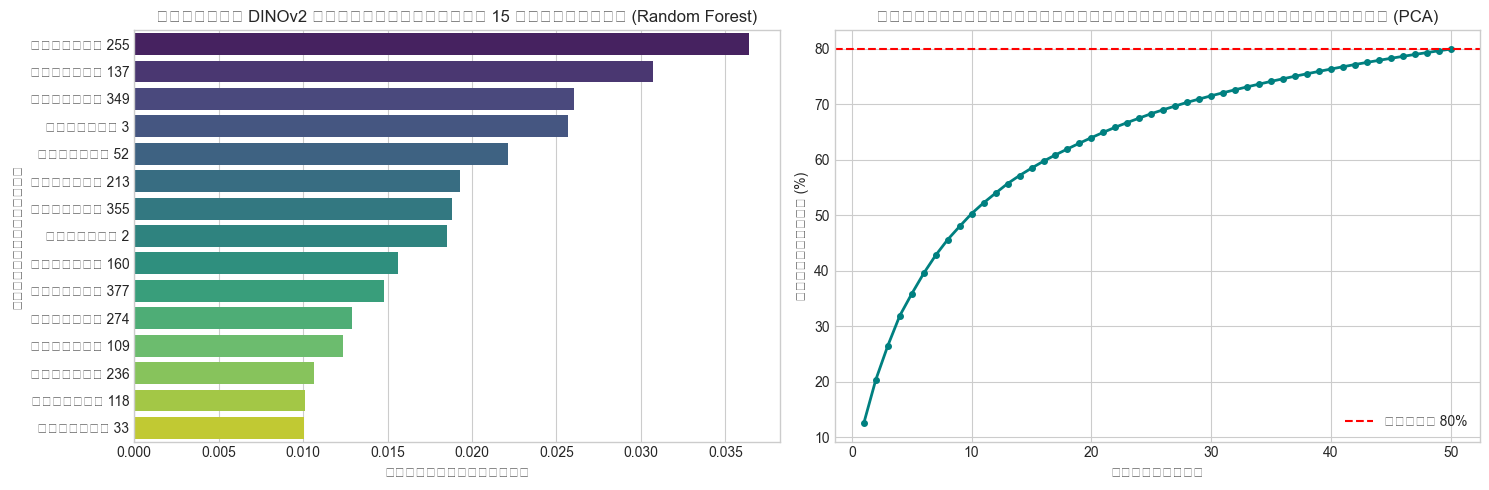

ข้อค้นพบ: ใช้แค่ 30 มิติแรก สามารถเก็บข้อมูลภาพได้ถึง 71.5%
มิติที่สำคัญที่สุด 5 อันดับแรก: [255, 137, 349, 3, 52]


In [9]:
from sklearn.decomposition import PCA

rf_model = trained_models['3. Random Forest']
importances = rf_model.feature_importances_
top_indices = np.argsort(importances)[::-1][:15]

pca = PCA(n_components=50, random_state=42)
pca.fit(X_train_norm)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=importances[top_indices], y=[f"มิติที่ {idx}" for idx in top_indices], ax=ax1, palette='viridis')
ax1.set_title('มิติของ DINOv2 ที่สำคัญที่สุด 15 อันดับแรก (Random Forest)')
ax1.set_xlabel('คะแนนความสำคัญ')
ax1.set_ylabel('มิติของฟีเจอร์')

ax2.plot(range(1, 51), cumulative_variance, marker='o', color='teal', linewidth=2, markersize=4)
ax2.axhline(y=80, color='r', linestyle='--', label='เกณฑ์ 80%')
ax2.set_title('ข้อมูลสะสมที่อธิบายได้เมื่อเพิ่มจำนวนมิติ (PCA)')
ax2.set_xlabel('จำนวนมิติ')
ax2.set_ylabel('ข้อมูลสะสม (%)')
ax2.legend()

plt.tight_layout()
output_plot_path = resolve_file('feature_importance_plot.png')
plt.savefig(output_plot_path, dpi=300)
plt.show()

print(f"ข้อค้นพบ: ใช้แค่ 30 มิติแรก สามารถเก็บข้อมูลภาพได้ถึง {cumulative_variance[29]:.1f}%")
print(f"มิติที่สำคัญที่สุด 5 อันดับแรก: {top_indices[:5].tolist()}")

---
## 8. สรุปผลการทดลองและการนำไปใช้จริง

### 8.1 สรุปผลการเปรียบเทียบโมเดล
1. **โมเดลเชิงเส้น (Logistic Regression และ Ridge)**:
   - ได้ความแม่นยำสูงมาก (มากกว่า 94-95%) เพราะโมเดล DINOv2 แปลงรูปภาพให้อยู่ในกลุ่มที่แยกจากกันได้ดีมากอยู่แล้ว
   - โมเดลทำงานเร็วและกินเครื่องน้อย เหมาะสำหรับเอาไปใส่ในอุปกรณ์พกพาเวลาลงพื้นที่จริง
2. **โมเดล Random Forest**:
   - จับความสัมพันธ์ที่ซับซ้อนของตัวเลขได้ดี และช่วยบอกเราได้ว่ามิติไหนมีความสำคัญต่อการแยกชนิดรูปภาพ

### 8.2 การนำไปใช้จริงในแปลงสำรวจ (ที่มีพืชหลายชนิดในแปลงเดียว)
- ถ่ายรูปแปลงสำรวจมุมกว้าง แล้วตัดแบ่งเป็นรูปย่อยๆ ตามจุดต่างๆ ในแปลง
- ส่งรูปย่อยแต่ละรูปเข้า DINOv2 เพื่อแปลงเป็นตัวเลข แล้วใช้ Vector Search ค้นหาชนิดพืชที่เหมือนที่สุด
- รวบรวมรายชื่อพืชทั้งหมดที่พบในแต่ละรูปย่อย ทำให้ได้รายชื่อพืชทั้งหมดในแปลงสำรวจนั้นได้ครบถ้วน

---
## สรุปคำถามท้ายบทและการแบ่งงาน

### สรุปคำตอบทั้ง 4 ข้อ
1. **Missing Values (ข้อ 1)**: คัดกรองรูปภาพก่อนใช้ โดยตัดรูปที่เสีย รูปที่เล็กกว่า 32x32 พิกเซลออก และแปลงเป็นโหมดสี RGB ทั้งหมด
2. **Feature Operations (ข้อ 2)**: แปลงเป็น RGB, ย่อรูปเป็น 224x224 พิกเซล, ปรับค่าสีด้วย ImageNet Mean/Std และจัดเรียงแกนข้อมูลให้พร้อมส่งเข้าโมเดล
3. **Data Leakage (ข้อ 3)**: แบ่งชุดข้อมูลก่อนเสมอ, ใช้โมเดลสำเร็จรูป DINOv2 สกัดฟีเจอร์โดยไม่ใช้เฉลย และคำนวณสถิติต่างๆ บนชุด Train เท่านั้น
4. **Feature Selection และโมเดล (ข้อ 4)**: สรุปภาพที่ควรใช้และไม่ควรใช้, เปรียบเทียบโมเดล 3 ตัว (Ridge ได้ความแม่นยำ 95.89%), ดูกลุ่มมิติที่สำคัญด้วย Random Forest และสร้างระบบค้นหาภาพด้วย Vector Search

### การมีส่วนร่วมของสมาชิก
| ชื่อ-สกุล | รหัสนิสิต | หน้าที่รับผิดชอบ |
|---|---|---|
| **ปิยังกูร ปัสสาวะกัง** | 6810405691 | ตรวจเช็คข้อมูล, กรองรูปภาพที่ผิดปกติ, วิเคราะห์การเตรียมรูปภาพ |
| **ศิวภูมิ พรหมจรรย์** | 6810405887 | ดึงฟีเจอร์ด้วย DINOv2, สร้างระบบ Vector Search, ทดสอบเปรียบเทียบโมเดล |

### การเปิดเผยการใช้งานปัญญาประดิษฐ์

ในงานนี้ กลุ่มของพวกเราได้ใช้ปัญญาประดิษฐ์ช่วยในการ:
1. ช่วยเรียบเรียงคำอธิบายให้เข้าใจง่าย ไม่ซับซ้อน และจัดหัวข้อให้เป็นระเบียบ
2. ช่วยตรวจสอบโค้ดการค้นหาภาพด้วยเวกเตอร์และการป้องกันข้อมูลรั่วไหล